Загружаем SBER...
Загружаем IMOEX...
Загружаем USD/RUB (USD000UTSTOM)...
Число строк после очистки: 2982
X_train: (1769, 20, 12) y_train: (1769, 1)
X_test: (1173, 20, 12) y_test: (1173, 1)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 20, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 20, 150)        │        97,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20, 150)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 20, 64)         │        41,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer_1               │ (None, 64)             │            84 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 40)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,997 (554.68 KB)

 Trainable params: 141,997 (554.68 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0221 - val_loss: 0.0040 - learning_rate: 0.0010
Epoch 2/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0053 - val_loss: 0.0097 - learning_rate: 0.0010
Epoch 3/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0047 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 4/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0037 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 5/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0036 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 6/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0035 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 7/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0038 - val_loss: 0.0028 - learning_rate: 0.0010
Epoch 8/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0035 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 9/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0030 - val_loss: 0.0023 - learning_rate: 0.0010
E

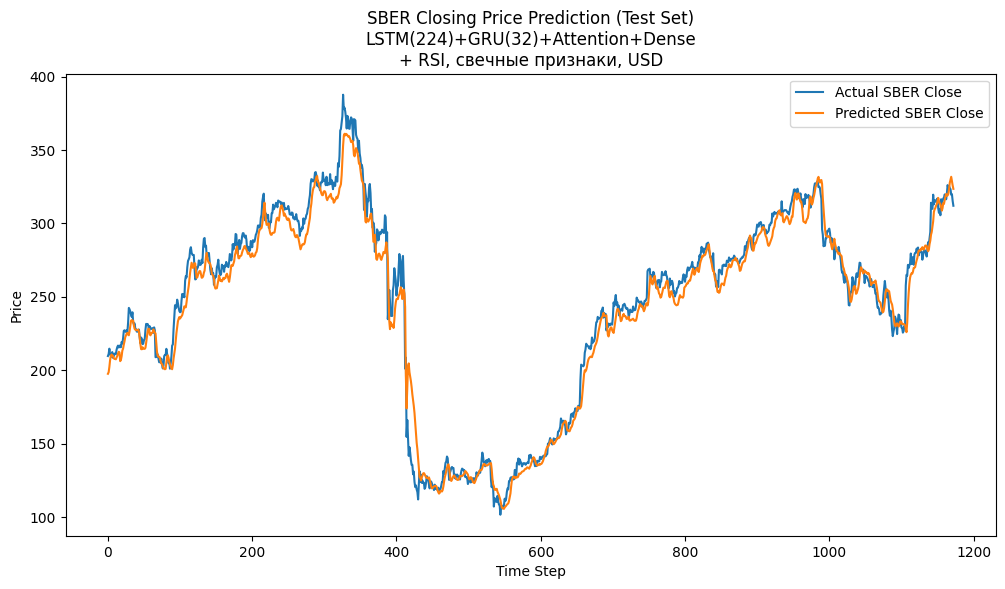

In [2]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error

# ============================================================
# Функция для загрузки данных с MOEX
# ============================================================
def fetch_moex_eod_data(security, engine, market, board, start_date, end_date):
    base_url = f"https://iss.moex.com/iss/history/engines/{engine}/markets/{market}/boards/{board}/securities/{security}.json"
    all_data = []
    columns = None
    offset = 0
    limit = 100

    while True:
        params = {"from": start_date, "till": end_date, "start": offset}
        response = requests.get(base_url, params=params)
        if response.status_code != 200:
            print(f"Ошибка: HTTP {response.status_code}")
            break
        data = response.json()
        try:
            if columns is None:
                columns = data["history"]["columns"]
            page_data = data["history"]["data"]
            if not page_data:
                break
            all_data.extend(page_data)
            if len(page_data) < limit:
                break
            offset += limit
        except KeyError:
            print("Ошибка формата данных.")
            break

    if all_data and columns:
        return pd.DataFrame(all_data, columns=columns)
    else:
        return None

# ============================================================
# Функция для расчёта RSI
# ============================================================
def compute_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.where(delta > 0, 0).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / (loss + 1e-10)
    rsi = 100 - (100 / (1 + rs))
    return rsi

# ============================================================
# Функция для предобработки данных для FastAPI
# ============================================================
def preprocess_data(df: pd.DataFrame, ticker: str) -> pd.DataFrame:
    # Приводим дату к datetime, сортируем и сбрасываем индекс
    df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"])
    df.sort_values("TRADEDATE", inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    # Переименование столбцов с добавлением тикера
    ticker = ticker.upper()
    close_col = f"CLOSE_{ticker}"
    open_col  = f"OPEN_{ticker}"
    high_col  = f"HIGH_{ticker}"
    low_col   = f"LOW_{ticker}"
    vol_col   = f"VOL_{ticker}"
    df.rename(columns={
        "CLOSE": close_col, 
        "OPEN": open_col, 
        "HIGH": high_col, 
        "LOW": low_col, 
        "VOLUME": vol_col
    }, inplace=True)
    
    # Вычисляем RSI
    rsi_col = f"RSI_{ticker}"
    df[rsi_col] = compute_rsi(df[close_col], period=14)
    df.dropna(subset=[rsi_col], inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    # Вычисляем свечные признаки:
    # BODY: абсолютная разница между CLOSE и OPEN
    body_col = f"BODY_{ticker}"
    df[body_col] = (df[close_col] - df[open_col]).abs()
    
    # UPPER_SHADOW: разница между HIGH и максимумом из (OPEN, CLOSE)
    upper_shadow_col = f"UPPER_SHADOW_{ticker}"
    df[upper_shadow_col] = df[high_col] - df[[open_col, close_col]].max(axis=1)
    
    # LOWER_SHADOW: разница между минимумом из (OPEN, CLOSE) и LOW
    lower_shadow_col = f"LOWER_SHADOW_{ticker}"
    df[lower_shadow_col] = df[[open_col, close_col]].min(axis=1) - df[low_col]
    
    # Дополнительный признак: VOLATILITY (7-дневное скользящее стандартное отклонение цены закрытия)
    volatility_col = f"VOLATILITY_{ticker}"
    df[volatility_col] = df[close_col].rolling(window=7).std()
    df.dropna(subset=[volatility_col], inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    return df

# ============================================================
# Кастомный слой внимания (Attention)
# ============================================================
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    
    def build(self, input_shape):
        hidden_dim = input_shape[-1]
        self.W = self.add_weight(name='att_weight', shape=(hidden_dim, 1), initializer='glorot_uniform')
        self.b = self.add_weight(name='att_bias', shape=(input_shape[1], 1), initializer='zeros')
        super().build(input_shape)
    
    def call(self, inputs):
        e = tf.tensordot(inputs, self.W, axes=[[2],[0]]) + self.b
        e = tf.squeeze(e, axis=-1)
        alpha = tf.nn.softmax(e)
        alpha = tf.expand_dims(alpha, axis=-1)
        context = inputs * alpha
        context = tf.reduce_sum(context, axis=1)
        return context

# ============================================================
# Основной скрипт для обучения модели
# ============================================================
if __name__ == "__main__":
    # 1. Параметры
    start_date = "2010-01-01"
    end_date = datetime.today().strftime("%Y-%m-%d")
    ticker = "SBER"
    
    # 2. Загрузка данных для тикера
    print(f"Загружаем {ticker}...")
    df_ticker = fetch_moex_eod_data(ticker, "stock", "shares", "TQBR", start_date, end_date)
    
    print("Загружаем IMOEX...")
    df_imoex = fetch_moex_eod_data("IMOEX", "stock", "index", "SNDX", start_date, end_date)
    
    print("Загружаем USD/RUB (USD000UTSTOM)...")
    df_usd = fetch_moex_eod_data("USD000UTSTOM", "currency", "selt", "CETS", start_date, end_date)
    
    if df_ticker is None or df_imoex is None or df_usd is None:
        raise ValueError("Ошибка при загрузке датасетов.")
    
    # Предобработка данных для тикера
    df_ticker_processed = preprocess_data(df_ticker, ticker=ticker)
    
    # Предобработка данных для других источников (оставляем как есть)
    df_imoex["TRADEDATE"] = pd.to_datetime(df_imoex["TRADEDATE"])
    df_imoex.sort_values("TRADEDATE", inplace=True)
    df_imoex.reset_index(drop=True, inplace=True)
    
    df_usd["TRADEDATE"] = pd.to_datetime(df_usd["TRADEDATE"])
    df_usd.sort_values("TRADEDATE", inplace=True)
    df_usd.reset_index(drop=True, inplace=True)
    
    # Объединяем данные по дате
    merged_df = df_ticker_processed.merge(
        df_imoex[["TRADEDATE", "CLOSE"]].rename(columns={"CLOSE": "CLOSE_IMOEX"}),
        on="TRADEDATE", how="outer")
    merged_df = merged_df.merge(
        df_usd[["TRADEDATE", "CLOSE"]].rename(columns={"CLOSE": "CLOSE_USD"}),
        on="TRADEDATE", how="outer")
    merged_df.sort_values("TRADEDATE", inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    
    # Удаляем строки с пропусками по ключевым признакам
    merged_df.dropna(subset=[f"CLOSE_{ticker}", "CLOSE_IMOEX", "CLOSE_USD"], inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    
    print(f"Число строк после очистки: {len(merged_df)}")
    
    # 3. Формирование признаков для FastAPI
    # Ожидается, что признаки начинаются с: OPEN, HIGH, LOW, CLOSE, VOL, RSI, BODY, UPPER_SHADOW, LOWER_SHADOW.
    # В нашем случае после preprocess_data для SBER получаем:
    # OPEN_SBER, HIGH_SBER, LOW_SBER, CLOSE_SBER, VOL_SBER, RSI_SBER, BODY_SBER, UPPER_SHADOW_SBER, LOWER_SHADOW_SBER, VOLATILITY_SBER
    features = [col for col in merged_df.columns if col.startswith(("OPEN", "HIGH", "LOW", "CLOSE", "VOL", "RSI", "BODY", "UPPER_SHADOW", "LOWER_SHADOW"))]
    target_cols = [f"CLOSE_{ticker}"]
    
    data = merged_df[features].values.astype(float)
    targets = merged_df[target_cols].values.astype(float)
    
    # 4. Разбиение на обучающую и тестовую выборки
    total_len = len(data)
    train_end = int(0.6 * total_len)
    train_data = data[:train_end]
    test_data  = data[train_end:]
    train_targets = targets[:train_end]
    test_targets  = targets[train_end:]
    
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    scaler_X.fit(train_data)
    scaler_y.fit(train_targets)
    
    train_data_scaled = scaler_X.transform(train_data)
    test_data_scaled  = scaler_X.transform(test_data)
    train_targets_scaled = scaler_y.transform(train_targets)
    test_targets_scaled  = scaler_y.transform(test_targets)
    
    # Функция формирования последовательностей (window length = 20)
    def create_sequences(X, y, seq_length=20):
        X_seq, y_seq = [], []
        for i in range(len(X) - seq_length):
            X_seq.append(X[i:i+seq_length])
            y_seq.append(y[i + seq_length])
        return np.array(X_seq), np.array(y_seq)
    
    seq_length = 20
    X_train, y_train = create_sequences(train_data_scaled, train_targets_scaled, seq_length)
    X_test, y_test = create_sequences(test_data_scaled, test_targets_scaled, seq_length)
    
    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_test:", X_test.shape, "y_test:", y_test.shape)
    # Ожидаемая форма: (None, 20, 10) (10 признаков)
    
    # 5. Построение модели (пример: LSTM + GRU + Attention + Dense)
    input_layer = Input(shape=(seq_length, len(features)))
    
    x = LSTM(150, return_sequences=True)(input_layer)
    x = Dropout(0.1)(x)
    
    x = GRU(64, return_sequences=True)(x)
    x = Dropout(0.1)(x)
    
    x = AttentionLayer()(x)
    
    x = Dense(40, activation="relu")(x)
    x = Dropout(0.15)(x)
    
    output_layer = Dense(1)(x)
    
    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer="Nadam", loss="mse")
    model.summary()
    
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)
    ]
    
    history = model.fit(
        X_train, y_train,
        epochs=40,
        batch_size=16,
        validation_split=0.1,
        callbacks=callbacks,
        verbose=1
    )
    
    # 6. Оценка модели и визуализация результатов
    test_loss = model.evaluate(X_test, y_test, verbose=1)
    print("Test Loss (MSE):", test_loss)
    
    preds_scaled = model.predict(X_test)
    preds = scaler_y.inverse_transform(preds_scaled)
    actuals = scaler_y.inverse_transform(y_test)
    
    mse_orig = mean_squared_error(actuals, preds)
    rmse_orig = np.sqrt(mse_orig)
    mae_orig = np.mean(np.abs(actuals - preds))
    mape_orig = np.mean(np.abs((actuals - preds) / actuals)) * 100
    
    print(f"MSE (рубли^2): {mse_orig:.3f}")
    print(f"RMSE (рубли):  {rmse_orig:.3f}")
    print(f"MAE (рубли):   {mae_orig:.3f}")
    print(f"MAPE:          {mape_orig:.2f}%")
    
    plt.figure(figsize=(12, 6))
    plt.plot(actuals, label="Actual SBER Close")
    plt.plot(preds, label="Predicted SBER Close")
    plt.title("SBER Closing Price Prediction (Test Set)\nLSTM(224)+GRU(32)+Attention+Dense\n+ RSI, свечные признаки, USD")
    plt.xlabel("Time Step")
    plt.ylabel("Price")
    plt.legend()
    plt.show()


In [2]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_orig = mean_squared_error(actuals, preds)
mae_orig = mean_absolute_error(actuals, preds)
rmse_orig = np.sqrt(mse_orig)

print(f"MSE (original scale, рубли^2): {mse_orig:.4f}")
print(f"RMSE (original scale, рубли):  {rmse_orig:.4f}")
print(f"MAE (original scale, рубли):   {mae_orig:.4f}")

mape = np.mean(np.abs(actuals - preds) / actuals) * 100
print(f"MAPE: {mape:.2f}%")

MSE (original scale, рубли^2): 51.9321
RMSE (original scale, рубли):  7.2064
MAE (original scale, рубли):   5.0228
MAPE: 2.20%


In [2]:
import pickle
import os

# Создаем папку для сохранения, если её нет
os.makedirs("../models", exist_ok=True)

ticker = "SBER"

# Определяем пути сохранения (используем нативный формат Keras)
model_save_path = f"../models/{ticker}_final_model.keras"
scaler_X_path = f"../models/{ticker}_scaler_X.pkl"
scaler_y_path = f"../models/{ticker}_scaler_y.pkl"

# Сохраняем модель
model.save(model_save_path)

# Сохраняем скейлеры
with open(scaler_X_path, "wb") as f:
    pickle.dump(scaler_X, f)
with open(scaler_y_path, "wb") as f:
    pickle.dump(scaler_y, f)

print(f"Модель и скейлеры для {ticker} успешно сохранены.")


Модель и скейлеры для SBER успешно сохранены.


# Pytorch version

[I 2025-03-29 21:07:40,875] A new study created in memory with name: no-name-5d4b3d39-3edd-4d69-84f9-bae46ffa0805


Данные загружены из кэша.


[I 2025-03-29 21:07:58,896] Trial 0 finished with value: 0.0729768716668736 and parameters: {'lstm_units': 87, 'fc_units': 200, 'dropout_rate': 0.25297275601581554, 'lr': 0.00015070373144282343, 'weight_decay': 3.578843326408332e-06}. Best is trial 0 with value: 0.0729768716668736.


Данные загружены из кэша.


[I 2025-03-29 21:08:22,455] Trial 1 finished with value: 0.002552070966986422 and parameters: {'lstm_units': 224, 'fc_units': 231, 'dropout_rate': 0.20538663652709788, 'lr': 0.00513999822172225, 'weight_decay': 1.4215323234422167e-06}. Best is trial 1 with value: 0.002552070966986422.


...

Данные загружены из кэша.


[I 2025-03-29 21:27:05,603] Trial 48 finished with value: 0.00225118546950398 and parameters: {'lstm_units': 258, 'fc_units': 106, 'dropout_rate': 0.1338510054401208, 'lr': 0.004311179562431155, 'weight_decay': 4.932420458307429e-05}. Best is trial 18 with value: 0.0016709481925419015.


Данные загружены из кэша.


[I 2025-03-29 21:27:33,414] Trial 49 finished with value: 0.002758397783812446 and parameters: {'lstm_units': 204, 'fc_units': 207, 'dropout_rate': 0.2961566539079422, 'lr': 0.0013436609424852994, 'weight_decay': 1.032058263303669e-06}. Best is trial 18 with value: 0.0016709481925419015.


Best trial:
    lstm_units: 196
    fc_units: 151
    dropout_rate: 0.13351299266216415
    lr: 0.0026886688214184788
    weight_decay: 4.7664426132397547e-05

Обучаем финальную модель с лучшими гиперпараметрами...
Данные загружены из кэша.
Epoch 1/40 - Loss: 0.0184 - Val Loss: 0.0257
Epoch 2/40 - Loss: 0.0064 - Val Loss: 0.0122
Epoch 3/40 - Loss: 0.0047 - Val Loss: 0.0031
Epoch 4/40 - Loss: 0.0048 - Val Loss: 0.0066
Epoch 5/40 - Loss: 0.0040 - Val Loss: 0.0036
Epoch 6/40 - Loss: 0.0034 - Val Loss: 0.0035
Epoch 7/40 - Loss: 0.0039 - Val Loss: 0.0044
Epoch 8/40 - Loss: 0.0035 - Val Loss: 0.0038
Epoch 9/40 - Loss: 0.0041 - Val Loss: 0.0079
Epoch 10/40 - Loss: 0.0032 - Val Loss: 0.0047
Epoch 11/40 - Loss: 0.0027 - Val Loss: 0.0048
Epoch 12/40 - Loss: 0.0027 - Val Loss: 0.0023
Epoch 13/40 - Loss: 0.0028 - Val Loss: 0.0056
Epoch 14/40 - Loss: 0.0033 - Val Loss: 0.0036
Epoch 15/40 - Loss: 0.0025 - Val Loss: 0.0055
Epoch 16/40 - Loss: 0.0029 - Val Loss: 0.0024
Epoch 17/40 - Loss: 0.0027 - Val

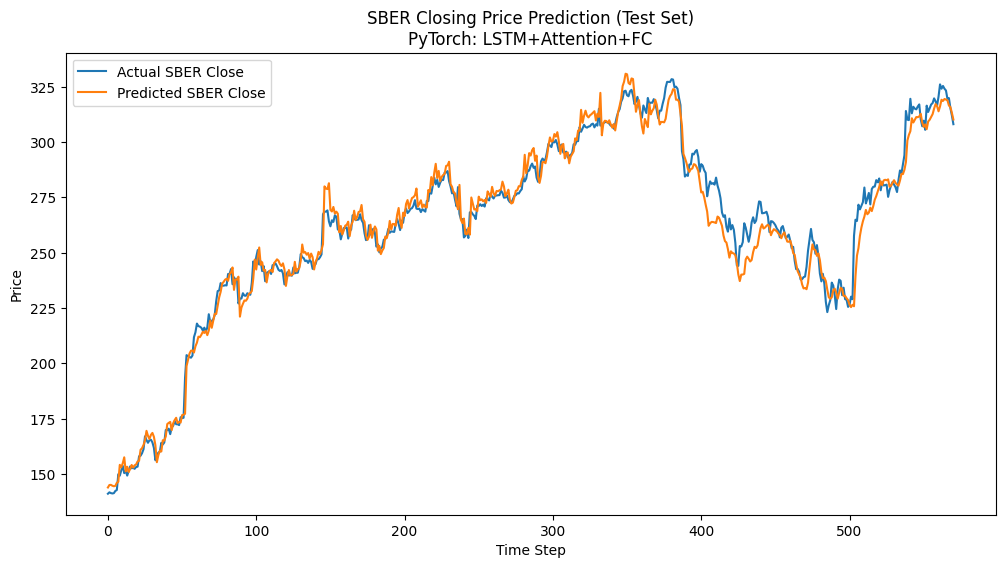

In [9]:
import os
import pickle
import requests
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import optuna

# ============================================================
# 1. Функции для загрузки данных и вычисления индикаторов
# ============================================================
def fetch_moex_eod_data(security, engine, market, board, start_date, end_date):
    base_url = f"https://iss.moex.com/iss/history/engines/{engine}/markets/{market}/boards/{board}/securities/{security}.json"
    all_data = []
    columns = None
    offset = 0
    limit = 100
    while True:
        params = {"from": start_date, "till": end_date, "start": offset}
        response = requests.get(base_url, params=params)
        if response.status_code != 200:
            print(f"Ошибка: HTTP {response.status_code}")
            break
        data = response.json()
        try:
            if columns is None:
                columns = data["history"]["columns"]
            page_data = data["history"]["data"]
            if not page_data:
                break
            all_data.extend(page_data)
            if len(page_data) < limit:
                break
            offset += limit
        except KeyError:
            print("Ошибка формата данных.")
            break
    if all_data and columns:
        return pd.DataFrame(all_data, columns=columns)
    else:
        return None

def compute_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()
    rs = avg_gain / (avg_loss + 1e-10)
    rsi = 100 - (100 / (1 + rs))
    return rsi

def compute_sma(series: pd.Series, window: int = 14) -> pd.Series:
    return series.rolling(window=window).mean()

# ============================================================
# 2. Функции для загрузки и кэширования сырых данных
# ============================================================
def load_raw_data(cache_file="raw_moex_data.pkl"):
    """
    Загружает данные с MOEX или из кэша, если файл существует.
    """
    if os.path.exists(cache_file):
        with open(cache_file, "rb") as f:
            merged_df = pickle.load(f)
        print("Данные загружены из кэша.")
        return merged_df

    ticker = "SBER"
    start_date = "2010-01-01"
    end_date = datetime.today().strftime("%Y-%m-%d")
    
    print("Загружаем данные SBER с MOEX...")
    sber_df = fetch_moex_eod_data(ticker, "stock", "shares", "TQBR", start_date, end_date)
    print("Загружаем IMOEX...")
    imoex_df = fetch_moex_eod_data("IMOEX", "stock", "index", "SNDX", start_date, end_date)
    print("Загружаем USD/RUB...")
    usd_df = fetch_moex_eod_data("USD000UTSTOM", "currency", "selt", "CETS", start_date, end_date)
    
    if sber_df is None or imoex_df is None or usd_df is None:
        raise ValueError("Ошибка при загрузке датасетов.")
    
    for df in [sber_df, imoex_df, usd_df]:
        df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"])
        df.sort_values("TRADEDATE", inplace=True)
        df.reset_index(drop=True, inplace=True)
    
    sber_df.rename(columns={"CLOSE": "CLOSE_SBER", "OPEN": "OPEN_SBER",
                            "HIGH": "HIGH_SBER", "LOW": "LOW_SBER", "VOLUME": "VOL_SBER"}, inplace=True)
    imoex_df.rename(columns={"CLOSE": "CLOSE_IMOEX"}, inplace=True)
    usd_df.rename(columns={"CLOSE": "CLOSE_USD"}, inplace=True)
    
    sber_df = sber_df[["TRADEDATE", "OPEN_SBER", "HIGH_SBER", "LOW_SBER", "CLOSE_SBER", "VOL_SBER"]]
    imoex_df = imoex_df[["TRADEDATE", "CLOSE_IMOEX"]]
    usd_df = usd_df[["TRADEDATE", "CLOSE_USD"]]
    
    merged_df = sber_df.merge(imoex_df, on="TRADEDATE", how="outer") \
                        .merge(usd_df, on="TRADEDATE", how="outer")
    merged_df.sort_values("TRADEDATE", inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    merged_df.dropna(subset=["CLOSE_SBER", "CLOSE_IMOEX", "CLOSE_USD"], inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    
    with open(cache_file, "wb") as f:
        pickle.dump(merged_df, f)
    print("Данные сохранены в кэш.")
    return merged_df

# ============================================================
# 3. Подготовка данных для обучения (без повторной загрузки)
# ============================================================
def prepare_data(raw_df):
    # Разбивка на train/test по времени (80% для тренировки)
    total_len = len(raw_df)
    train_end = int(0.8 * total_len)
    train_df = raw_df.iloc[:train_end].copy()
    test_df  = raw_df.iloc[train_end:].copy()
    
    # Вычисляем индикаторы отдельно для train и test (без утечки)
    train_df["RSI_SBER"] = compute_rsi(train_df["CLOSE_SBER"], period=14)
    train_df["SMA_SBER"] = compute_sma(train_df["CLOSE_SBER"], window=14)
    test_df["RSI_SBER"] = compute_rsi(test_df["CLOSE_SBER"], period=14)
    test_df["SMA_SBER"] = compute_sma(test_df["CLOSE_SBER"], window=14)
    
    train_df.dropna(subset=["RSI_SBER", "SMA_SBER"], inplace=True)
    test_df.dropna(subset=["RSI_SBER", "SMA_SBER"], inplace=True)
    train_df.reset_index(drop=True, inplace=True)
    test_df.reset_index(drop=True, inplace=True)
    
    features = ["OPEN_SBER", "HIGH_SBER", "LOW_SBER", "CLOSE_SBER", "VOL_SBER",
                "CLOSE_IMOEX", "CLOSE_USD", "RSI_SBER", "SMA_SBER"]
    target_col = "CLOSE_SBER"
    
    train_data = train_df[features].values.astype(float)
    test_data  = test_df[features].values.astype(float)
    train_targets = train_df[[target_col]].values.astype(float)
    test_targets  = test_df[[target_col]].values.astype(float)
    
    scaler_X = RobustScaler()
    scaler_y = RobustScaler()
    scaler_X.fit(train_data)
    scaler_y.fit(train_targets)
    train_data_scaled = scaler_X.transform(train_data)
    test_data_scaled  = scaler_X.transform(test_data)
    train_targets_scaled = scaler_y.transform(train_targets)
    test_targets_scaled  = scaler_y.transform(test_targets)
    
    seq_length = 20
    X_train, y_train = create_sequences(train_data_scaled, train_targets_scaled, seq_length)
    X_test, y_test = create_sequences(test_data_scaled, test_targets_scaled, seq_length)
    
    train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                                  torch.tensor(y_train, dtype=torch.float32))
    test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                                 torch.tensor(y_test, dtype=torch.float32))
    
    return train_dataset, test_dataset, scaler_y, seq_length, len(features)

def create_sequences(X, y, seq_length=20):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

# ============================================================
# 4. Определение модели на PyTorch
# ============================================================
class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim, timesteps):
        super(AttentionLayer, self).__init__()
        self.hidden_dim = hidden_dim
        self.timesteps = timesteps
        self.W = nn.Parameter(torch.Tensor(hidden_dim, 1))
        self.b = nn.Parameter(torch.zeros(timesteps, 1))
        self.reset_parameters()
    
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.W)
    
    def forward(self, x):
        e = torch.matmul(x, self.W) + self.b  # (batch, timesteps, 1)
        e = e.squeeze(-1)  # (batch, timesteps)
        alpha = torch.softmax(e, dim=1)  # (batch, timesteps)
        alpha = alpha.unsqueeze(-1)  # (batch, timesteps, 1)
        context = x * alpha
        context = torch.sum(context, dim=1)
        return context

class PricePredictionModel(nn.Module):
    def __init__(self, seq_length, num_features, output_dim, lstm_units, fc_units, dropout_rate):
        super(PricePredictionModel, self).__init__()
        self.lstm = nn.LSTM(input_size=num_features, hidden_size=lstm_units, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.attention = AttentionLayer(hidden_dim=lstm_units, timesteps=seq_length)
        self.fc1 = nn.Linear(lstm_units, fc_units)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(fc_units, output_dim)
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        x = self.dropout(lstm_out)
        attn_out = self.attention(x)
        x = self.fc1(attn_out)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# ============================================================
# 5. Оптимизация гиперпараметров с помощью Optuna
# ============================================================
def objective(trial):
    # Используем глобальные кэшированные данные
    raw_df = load_raw_data()
    train_dataset, test_dataset, _, seq_length, num_features = prepare_data(raw_df)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)
    
    lstm_units = trial.suggest_int("lstm_units", 50, 400)
    fc_units   = trial.suggest_int("fc_units", 32, 300)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    
    device = torch.device("mps" if torch.backends.mps.is_available() 
                          else "cuda" if torch.cuda.is_available() else "cpu")
    model = PricePredictionModel(seq_length, num_features, output_dim=1,
                                 lstm_units=lstm_units, fc_units=fc_units, dropout_rate=dropout_rate)
    model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
    
    num_epochs = 40
    patience = 5
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    for epoch in range(num_epochs):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())
        avg_train_loss = np.mean(train_losses)
        
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_losses.append(loss.item())
        avg_val_loss = np.mean(val_losses)
        scheduler.step(avg_val_loss)
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break
        if device.type == 'cuda':
            torch.cuda.empty_cache()
    return best_val_loss

# ============================================================
# 6. Финальное обучение модели с лучшими гиперпараметрами
# ============================================================
def train_final_model(best_params):
    raw_df = load_raw_data()
    train_dataset, test_dataset, scaler_y, seq_length, num_features = prepare_data(raw_df)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)
    
    device = torch.device("mps" if torch.backends.mps.is_available() 
                          else "cuda" if torch.cuda.is_available() else "cpu")
    
    model = PricePredictionModel(seq_length, num_features, output_dim=1,
                                 lstm_units=best_params["lstm_units"],
                                 fc_units=best_params["fc_units"],
                                 dropout_rate=best_params["dropout_rate"])
    model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
    
    num_epochs = 40
    patience = 10
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None
    
    for epoch in range(num_epochs):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())
        avg_train_loss = np.mean(train_losses)
        
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_losses.append(loss.item())
        avg_val_loss = np.mean(val_losses)
        scheduler.step(avg_val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_state = model.state_dict()
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping!")
                break
        if device.type == 'cuda':
            torch.cuda.empty_cache()
    
    model.load_state_dict(best_model_state)
    
    model.eval()
    test_losses = []
    preds_list = []
    actual_list = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            test_losses.append(loss.item())
            preds_list.append(outputs.cpu().numpy())
            actual_list.append(y_batch.cpu().numpy())
    avg_test_loss = np.mean(test_losses)
    print("Test Loss (MSE):", avg_test_loss)
    
    preds = np.concatenate(preds_list, axis=0)
    actuals = np.concatenate(actual_list, axis=0)
    
    preds_inv = scaler_y.inverse_transform(preds)
    actuals_inv = scaler_y.inverse_transform(actuals)
    
    mse_orig = mean_squared_error(actuals_inv, preds_inv)
    rmse_orig = np.sqrt(mse_orig)
    mae_orig = np.mean(np.abs(actuals_inv - preds_inv))
    mape_orig = np.mean(np.abs((actuals_inv - preds_inv) / actuals_inv)) * 100
    
    print(f"Метрики для SBER:")
    print(f"MSE (рубли^2): {mse_orig:.3f}")
    print(f"RMSE (рубли):  {rmse_orig:.3f}")
    print(f"MAE (рубли):   {mae_orig:.3f}")
    print(f"MAPE:          {mape_orig:.2f}%")
    
    plt.figure(figsize=(12,6))
    plt.plot(actuals_inv.flatten(), label="Actual SBER Close")
    plt.plot(preds_inv.flatten(), label="Predicted SBER Close")
    plt.title("SBER Closing Price Prediction (Test Set)\nPyTorch: LSTM+Attention+FC")
    plt.xlabel("Time Step")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

# ============================================================
# 7. Запуск Optuna и финальное обучение
# ============================================================
if __name__ == "__main__":
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=50)  # Увеличьте число испытаний при необходимости
    print("Best trial:")
    trial = study.best_trial
    for key, value in trial.params.items():
        print(f"    {key}: {value}")
    
    print("\nОбучаем финальную модель с лучшими гиперпараметрами...")
    train_final_model(trial.params)


Данные загружены из кэша.
Epoch 1/40 - Train Loss: 0.0193 - Val Loss: 0.0367
Epoch 2/40 - Train Loss: 0.0069 - Val Loss: 0.0113
Epoch 3/40 - Train Loss: 0.0046 - Val Loss: 0.0156
Epoch 4/40 - Train Loss: 0.0049 - Val Loss: 0.0029
Epoch 5/40 - Train Loss: 0.0054 - Val Loss: 0.0074
Epoch 6/40 - Train Loss: 0.0036 - Val Loss: 0.0066
Epoch 7/40 - Train Loss: 0.0036 - Val Loss: 0.0057
Epoch 8/40 - Train Loss: 0.0037 - Val Loss: 0.0023
Epoch 9/40 - Train Loss: 0.0031 - Val Loss: 0.0093
Epoch 10/40 - Train Loss: 0.0031 - Val Loss: 0.0016
Epoch 11/40 - Train Loss: 0.0036 - Val Loss: 0.0036
Epoch 12/40 - Train Loss: 0.0033 - Val Loss: 0.0015
Epoch 13/40 - Train Loss: 0.0027 - Val Loss: 0.0032
Epoch 14/40 - Train Loss: 0.0033 - Val Loss: 0.0122
Epoch 15/40 - Train Loss: 0.0032 - Val Loss: 0.0032
Epoch 16/40 - Train Loss: 0.0031 - Val Loss: 0.0020
Epoch 17/40 - Train Loss: 0.0032 - Val Loss: 0.0029
Epoch 18/40 - Train Loss: 0.0029 - Val Loss: 0.0018
Epoch 19/40 - Train Loss: 0.0027 - Val Loss: 0.

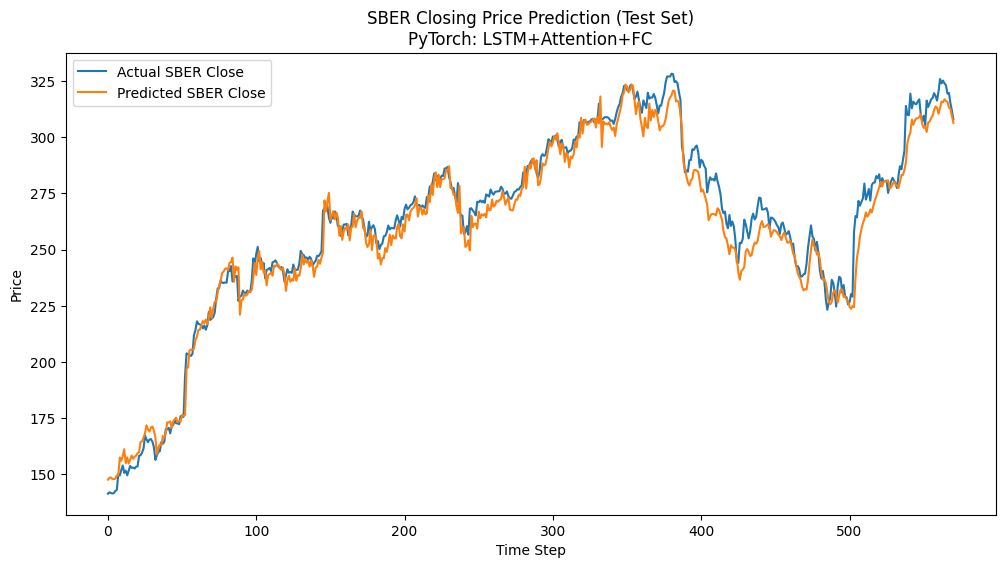


Модель и скейлеры сохранены в папке 'models'.


In [ ]:
import os
import pickle
import requests
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

def fetch_moex_eod_data(security, engine, market, board, start_date, end_date):
    base_url = f"https://iss.moex.com/iss/history/engines/{engine}/markets/{market}/boards/{board}/securities/{security}.json"
    all_data = []
    columns = None
    offset = 0
    limit = 100
    while True:
        params = {"from": start_date, "till": end_date, "start": offset}
        response = requests.get(base_url, params=params)
        if response.status_code != 200:
            print(f"Ошибка: HTTP {response.status_code}")
            break
        data = response.json()
        try:
            if columns is None:
                columns = data["history"]["columns"]
            page_data = data["history"]["data"]
            if not page_data:
                break
            all_data.extend(page_data)
            if len(page_data) < limit:
                break
            offset += limit
        except KeyError:
            print("Ошибка формата данных.")
            break
    if all_data and columns:
        return pd.DataFrame(all_data, columns=columns)
    else:
        return None

def compute_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()
    rs = avg_gain / (avg_loss + 1e-10)
    rsi = 100 - (100 / (1 + rs))
    return rsi

def compute_sma(series: pd.Series, window: int = 14) -> pd.Series:
    return series.rolling(window=window).mean()


# Если данные уже сохранены в кэше, они будут загружены из файла `raw_moex_data.pkl`.

def load_raw_data(cache_file="raw_moex_data.pkl"):
    if os.path.exists(cache_file):
        with open(cache_file, "rb") as f:
            merged_df = pickle.load(f)
        print("Данные загружены из кэша.")
        return merged_df

    ticker = "SBER"
    start_date = "2010-01-01"
    end_date = datetime.today().strftime("%Y-%m-%d")
    
    print("Загружаем данные SBER с MOEX...")
    sber_df = fetch_moex_eod_data(ticker, "stock", "shares", "TQBR", start_date, end_date)
    print("Загружаем IMOEX...")
    imoex_df = fetch_moex_eod_data("IMOEX", "stock", "index", "SNDX", start_date, end_date)
    print("Загружаем USD/RUB...")
    usd_df = fetch_moex_eod_data("USD000UTSTOM", "currency", "selt", "CETS", start_date, end_date)
    
    if sber_df is None or imoex_df is None or usd_df is None:
        raise ValueError("Ошибка при загрузке датасетов.")
    
    for df in [sber_df, imoex_df, usd_df]:
        df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"])
        df.sort_values("TRADEDATE", inplace=True)
        df.reset_index(drop=True, inplace=True)
    
    sber_df.rename(columns={"CLOSE": "CLOSE_SBER", "OPEN": "OPEN_SBER",
                            "HIGH": "HIGH_SBER", "LOW": "LOW_SBER", "VOLUME": "VOL_SBER"}, inplace=True)
    imoex_df.rename(columns={"CLOSE": "CLOSE_IMOEX"}, inplace=True)
    usd_df.rename(columns={"CLOSE": "CLOSE_USD"}, inplace=True)
    
    sber_df = sber_df[["TRADEDATE", "OPEN_SBER", "HIGH_SBER", "LOW_SBER", "CLOSE_SBER", "VOL_SBER"]]
    imoex_df = imoex_df[["TRADEDATE", "CLOSE_IMOEX"]]
    usd_df = usd_df[["TRADEDATE", "CLOSE_USD"]]
    
    merged_df = sber_df.merge(imoex_df, on="TRADEDATE", how="outer") \
                        .merge(usd_df, on="TRADEDATE", how="outer")
    merged_df.sort_values("TRADEDATE", inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    merged_df.dropna(subset=["CLOSE_SBER", "CLOSE_IMOEX", "CLOSE_USD"], inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    
    with open(cache_file, "wb") as f:
        pickle.dump(merged_df, f)
    print("Данные сохранены в кэш.")
    return merged_df

def create_sequences(X, y, seq_length=20):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

def prepare_data(raw_df):
    total_len = len(raw_df)
    train_end = int(0.8 * total_len)
    train_df = raw_df.iloc[:train_end].copy()
    test_df  = raw_df.iloc[train_end:].copy()
    
    train_df["RSI_SBER"] = compute_rsi(train_df["CLOSE_SBER"], period=14)
    train_df["SMA_SBER"] = compute_sma(train_df["CLOSE_SBER"], window=14)
    test_df["RSI_SBER"] = compute_rsi(test_df["CLOSE_SBER"], period=14)
    test_df["SMA_SBER"] = compute_sma(test_df["CLOSE_SBER"], window=14)
    
    train_df.dropna(subset=["RSI_SBER", "SMA_SBER"], inplace=True)
    test_df.dropna(subset=["RSI_SBER", "SMA_SBER"], inplace=True)
    train_df.reset_index(drop=True, inplace=True)
    test_df.reset_index(drop=True, inplace=True)
    
    features = ["OPEN_SBER", "HIGH_SBER", "LOW_SBER", "CLOSE_SBER", "VOL_SBER",
                "CLOSE_IMOEX", "CLOSE_USD", "RSI_SBER", "SMA_SBER"]
    target_col = "CLOSE_SBER"
    
    train_data = train_df[features].values.astype(float)
    test_data  = test_df[features].values.astype(float)
    train_targets = train_df[[target_col]].values.astype(float)
    test_targets  = test_df[[target_col]].values.astype(float)
    
    scaler_X = RobustScaler()
    scaler_y = RobustScaler()
    scaler_X.fit(train_data)
    scaler_y.fit(train_targets)
    train_data_scaled = scaler_X.transform(train_data)
    test_data_scaled  = scaler_X.transform(test_data)
    train_targets_scaled = scaler_y.transform(train_targets)
    test_targets_scaled  = scaler_y.transform(test_targets)
    
    seq_length = 20
    X_train, y_train = create_sequences(train_data_scaled, train_targets_scaled, seq_length)
    X_test, y_test = create_sequences(test_data_scaled, test_targets_scaled, seq_length)
    
    train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                                  torch.tensor(y_train, dtype=torch.float32))
    test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                                 torch.tensor(y_test, dtype=torch.float32))
    
    return train_dataset, test_dataset, scaler_X, scaler_y, seq_length, len(features)

class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim, timesteps):
        super(AttentionLayer, self).__init__()
        self.hidden_dim = hidden_dim
        self.timesteps = timesteps
        self.W = nn.Parameter(torch.Tensor(hidden_dim, 1))
        self.b = nn.Parameter(torch.zeros(timesteps, 1))
        self.reset_parameters()
    
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.W)
    
    def forward(self, x):
        # x: (batch, timesteps, hidden_dim)
        e = torch.matmul(x, self.W) + self.b  # (batch, timesteps, 1)
        e = e.squeeze(-1)  # (batch, timesteps)
        alpha = torch.softmax(e, dim=1)  # (batch, timesteps)
        alpha = alpha.unsqueeze(-1)  # (batch, timesteps, 1)
        context = x * alpha
        context = torch.sum(context, dim=1)
        return context

class PricePredictionModel(nn.Module):
    def __init__(self, seq_length, num_features, output_dim, lstm_units, fc_units, dropout_rate):
        super(PricePredictionModel, self).__init__()
        self.lstm = nn.LSTM(input_size=num_features, hidden_size=lstm_units, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.attention = AttentionLayer(hidden_dim=lstm_units, timesteps=seq_length)
        self.fc1 = nn.Linear(lstm_units, fc_units)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(fc_units, output_dim)
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        x = self.dropout(lstm_out)
        attn_out = self.attention(x)
        x = self.fc1(attn_out)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# 5. Обучение модели с зафиксированными гиперпараметрами
# 
# Используем следующие гиперпараметры (лучший вариант):
# 
# - `lstm_units` = 196  
# - `fc_units` = 151  
# - `dropout_rate` = 0.13351299266216415  
# - `lr` = 0.0026886688214184788  
# - `weight_decay` = 4.7664426132397547e-05  
# - Количество эпох = 40  
# - Batch size = 16  
# - Early stopping при 10 эпохах без улучшения

def train_final_model():
    # Загрузка данных
    raw_df = load_raw_data()
    train_dataset, test_dataset, scaler_X, scaler_y, seq_length, num_features = prepare_data(raw_df)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Фиксированные гиперпараметры
    lstm_units = 196
    fc_units = 151
    dropout_rate = 0.13351299266216415
    lr = 0.0026886688214184788
    weight_decay = 4.7664426132397547e-05
    
    model = PricePredictionModel(seq_length, num_features, output_dim=1,
                                 lstm_units=lstm_units, fc_units=fc_units, dropout_rate=dropout_rate)
    model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
    
    num_epochs = 40
    patience = 10
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None
    
    for epoch in range(num_epochs):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())
        avg_train_loss = np.mean(train_losses)
        
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_losses.append(loss.item())
        avg_val_loss = np.mean(val_losses)
        scheduler.step(avg_val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_state = model.state_dict()
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping!")
                break
        if device.type == 'cuda':
            torch.cuda.empty_cache()
    
    model.load_state_dict(best_model_state)
    
    # Оценка модели
    model.eval()
    test_losses = []
    preds_list = []
    actual_list = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            test_losses.append(loss.item())
            preds_list.append(outputs.cpu().numpy())
            actual_list.append(y_batch.cpu().numpy())
    avg_test_loss = np.mean(test_losses)
    print("Test Loss (MSE):", avg_test_loss)
    
    preds = np.concatenate(preds_list, axis=0)
    actuals = np.concatenate(actual_list, axis=0)
    
    preds_inv = scaler_y.inverse_transform(preds)
    actuals_inv = scaler_y.inverse_transform(actuals)
    
    mse_orig = mean_squared_error(actuals_inv, preds_inv)
    rmse_orig = np.sqrt(mse_orig)
    mae_orig = np.mean(np.abs(actuals_inv - preds_inv))
    mape_orig = np.mean(np.abs((actuals_inv - preds_inv) / actuals_inv)) * 100
    
    print(f"\nМетрики для SBER:")
    print(f"MSE (рубли^2): {mse_orig:.3f}")
    print(f"RMSE (рубли):  {rmse_orig:.3f}")
    print(f"MAE (рубли):   {mae_orig:.3f}")
    print(f"MAPE:          {mape_orig:.2f}%")
    
    plt.figure(figsize=(12,6))
    plt.plot(actuals_inv.flatten(), label="Actual SBER Close")
    plt.plot(preds_inv.flatten(), label="Predicted SBER Close")
    plt.title("SBER Closing Price Prediction (Test Set)\nPyTorch: LSTM+Attention+FC")
    plt.xlabel("Time Step")
    plt.ylabel("Price")
    plt.legend()
    plt.show()
    
    # Сохранение модели и скейлеров
    os.makedirs("../models", exist_ok=True)
    model_path = os.path.join("../models", "SBER_model.pth")
    scaler_X_path = os.path.join("../models", "SBER_scaler_X.pkl")
    scaler_y_path = os.path.join("../models", "SBER_scaler_y.pkl")
    
    torch.save(model.state_dict(), model_path)
    with open(scaler_X_path, "wb") as f:
        pickle.dump(scaler_X, f)
    with open(scaler_y_path, "wb") as f:
        pickle.dump(scaler_y, f)
    print(f"\nМодель и скейлеры сохранены в папке 'models'.")
    
if __name__ == "__main__":
    train_final_model()


Данные загружены из кэша.
Epoch 1/40 | Train Loss: 0.0256 | Val Loss: 0.0029
Epoch 2/40 | Train Loss: 0.0076 | Val Loss: 0.0080
Epoch 3/40 | Train Loss: 0.0077 | Val Loss: 0.0028
Epoch 4/40 | Train Loss: 0.0082 | Val Loss: 0.0056
Epoch 5/40 | Train Loss: 0.0056 | Val Loss: 0.0070
Epoch 6/40 | Train Loss: 0.0064 | Val Loss: 0.0092
Epoch 7/40 | Train Loss: 0.0044 | Val Loss: 0.0041
Epoch 8/40 | Train Loss: 0.0051 | Val Loss: 0.0056
Epoch 9/40 | Train Loss: 0.0043 | Val Loss: 0.0036
Epoch 10/40 | Train Loss: 0.0037 | Val Loss: 0.0028
Epoch 11/40 | Train Loss: 0.0037 | Val Loss: 0.0047
Epoch 12/40 | Train Loss: 0.0035 | Val Loss: 0.0042
Epoch 13/40 | Train Loss: 0.0033 | Val Loss: 0.0018
Epoch 14/40 | Train Loss: 0.0032 | Val Loss: 0.0030
Epoch 15/40 | Train Loss: 0.0038 | Val Loss: 0.0037
Epoch 16/40 | Train Loss: 0.0037 | Val Loss: 0.0040
Epoch 17/40 | Train Loss: 0.0031 | Val Loss: 0.0033
Epoch 18/40 | Train Loss: 0.0036 | Val Loss: 0.0024
Epoch 19/40 | Train Loss: 0.0032 | Val Loss: 0.

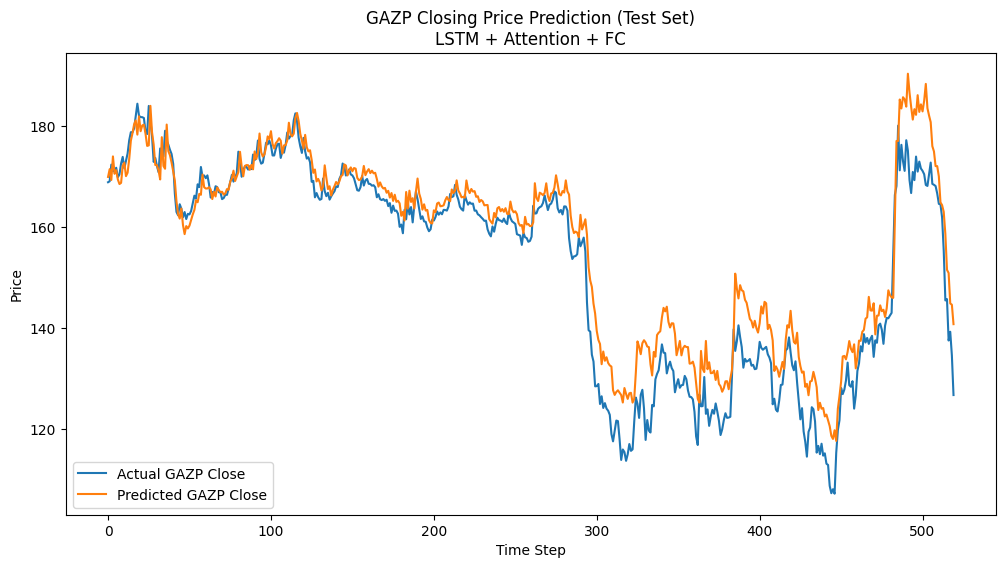

In [1]:
import os
import pickle
import requests
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ----------------------- Настройки и финансовые константы -----------------------
SEQ_LENGTH = 20          # Окно для временного ряда
TRAIN_TEST_RATIO = 0.8   # Доля данных для обучения
RSI_PERIOD = 14          # Период для расчёта RSI
SMA_WINDOW = 14          # Окно для скользящей средней
SEED = 42
TICKER = "GAZP"          # Меняем тикер здесь

torch.manual_seed(SEED)
np.random.seed(SEED)

# ----------------------- 1. Загрузка данных с MOEX -----------------------
def fetch_moex_eod_data(security, engine, market, board, start_date, end_date):
    base_url = f"https://iss.moex.com/iss/history/engines/{engine}/markets/{market}/boards/{board}/securities/{security}.json"
    all_data = []
    columns = None
    offset = 0
    limit = 100
    while True:
        params = {"from": start_date, "till": end_date, "start": offset}
        response = requests.get(base_url, params=params)
        if response.status_code != 200:
            print(f"Ошибка: HTTP {response.status_code}")
            break
        data = response.json()
        try:
            if columns is None:
                columns = data["history"]["columns"]
            page_data = data["history"]["data"]
            if not page_data:
                break
            all_data.extend(page_data)
            if len(page_data) < limit:
                break
            offset += limit
        except KeyError:
            print("Ошибка формата данных.")
            break
    if all_data and columns:
        return pd.DataFrame(all_data, columns=columns)
    else:
        return None

# ----------------------- 2. Технические индикаторы и финансовые преобразования -----------------------
def compute_rsi(series: pd.Series, period: int = RSI_PERIOD) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()
    rs = avg_gain / (avg_loss + 1e-10)
    return 100 - (100 / (1 + rs))

def compute_sma(series: pd.Series, window: int = SMA_WINDOW) -> pd.Series:
    return series.rolling(window=window).mean()

def compute_log_returns(series: pd.Series, window: int = 1) -> pd.Series:
    """Логарифмическая доходность для стабилизации ряда."""
    return np.log(series).diff(window)

def compute_volatility(series: pd.Series, window: int = SMA_WINDOW) -> pd.Series:
    """Волатильность как стандартное отклонение лог-доходностей."""
    returns = compute_log_returns(series)
    return returns.rolling(window=window).std()

def compute_macd(series: pd.Series, fast_period=12, slow_period=26, signal_period=9):
    """MACD: разница между быстрым и медленным EMA, сигнальная линия и гистограмма."""
    ema_fast = series.ewm(span=fast_period, adjust=False).mean()
    ema_slow = series.ewm(span=slow_period, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal_period, adjust=False).mean()
    macd_hist = macd_line - signal_line
    return macd_line, signal_line, macd_hist

def compute_bollinger_bands(series: pd.Series, window=20, num_std=2):
    """Bollinger Bands: верхняя, нижняя границы и SMA."""
    sma = series.rolling(window=window).mean()
    std = series.rolling(window=window).std()
    upper_band = sma + (std * num_std)
    lower_band = sma - (std * num_std)
    return upper_band, lower_band, sma

def compute_atr(df: pd.DataFrame, ticker: str, window: int = 14) -> pd.Series:
    """ATR: средний истинный диапазон для оценки волатильности."""
    high_col = f"HIGH_{ticker}"
    low_col = f"LOW_{ticker}"
    close_col = f"CLOSE_{ticker}"
    high_low = df[high_col] - df[low_col]
    high_prev_close = np.abs(df[high_col] - df[close_col].shift(1))
    low_prev_close = np.abs(df[low_col] - df[close_col].shift(1))
    true_range = pd.concat([high_low, high_prev_close, low_prev_close], axis=1).max(axis=1)
    atr = true_range.rolling(window=window).mean()
    return atr

# ----------------------- 3. Загрузка и кэширование данных -----------------------
def load_raw_data(ticker=TICKER, cache_file="raw_moex_data.pkl"):
    if os.path.exists(cache_file):
        with open(cache_file, "rb") as f:
            merged_df = pickle.load(f)
        print("Данные загружены из кэша.")
        return merged_df

    start_date = "2010-01-01"
    end_date = datetime.today().strftime("%Y-%m-%d")
    
    print(f"Загружаем данные {ticker} с MOEX...")
    ticker_df = fetch_moex_eod_data(ticker, "stock", "shares", "TQBR", start_date, end_date)
    print("Загружаем IMOEX...")
    imoex_df = fetch_moex_eod_data("IMOEX", "stock", "index", "SNDX", start_date, end_date)
    print("Загружаем USD/RUB...")
    usd_df = fetch_moex_eod_data("USD000UTSTOM", "currency", "selt", "CETS", start_date, end_date)
    
    if ticker_df is None or imoex_df is None or usd_df is None:
        raise ValueError("Ошибка при загрузке датасетов.")
    
    for df in [ticker_df, imoex_df, usd_df]:
        df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"])
        df.sort_values("TRADEDATE", inplace=True)
        df.reset_index(drop=True, inplace=True)
    
    # Переименовываем столбцы для выбранного тикера
    ticker_df.rename(columns={
        "CLOSE": f"CLOSE_{ticker}",
        "OPEN": f"OPEN_{ticker}",
        "HIGH": f"HIGH_{ticker}",
        "LOW": f"LOW_{ticker}",
        "VOLUME": f"VOL_{ticker}"
    }, inplace=True)
    imoex_df.rename(columns={"CLOSE": "CLOSE_IMOEX"}, inplace=True)
    usd_df.rename(columns={"CLOSE": "CLOSE_USD"}, inplace=True)
    
    ticker_df = ticker_df[["TRADEDATE", f"OPEN_{ticker}", f"HIGH_{ticker}", f"LOW_{ticker}", f"CLOSE_{ticker}", f"VOL_{ticker}"]]
    imoex_df = imoex_df[["TRADEDATE", "CLOSE_IMOEX"]]
    usd_df = usd_df[["TRADEDATE", "CLOSE_USD"]]
    
    merged_df = ticker_df.merge(imoex_df, on="TRADEDATE", how="outer") \
                         .merge(usd_df, on="TRADEDATE", how="outer")
    merged_df.sort_values("TRADEDATE", inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    merged_df.dropna(subset=[f"CLOSE_{ticker}", "CLOSE_IMOEX", "CLOSE_USD"], inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    
    with open(cache_file, "wb") as f:
        pickle.dump(merged_df, f)
    print("Данные сохранены в кэш.")
    return merged_df

# ----------------------- 4. Подготовка данных для модели -----------------------
def create_sequences(X, y, seq_length=SEQ_LENGTH):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

def prepare_data(raw_df: pd.DataFrame, ticker=TICKER):
    df = raw_df.copy()
    
    # Исходные финансовые признаки для выбранного тикера
    close_col = f"CLOSE_{ticker}"
    df['LOG_RETURNS'] = compute_log_returns(df[close_col])
    df['RSI'] = compute_rsi(df[close_col])
    df['SMA'] = compute_sma(df[close_col])
    df['VOLATILITY'] = compute_volatility(df[close_col])
    
    # Преобразование SMA в доходность (индикатор тренда)
    df['SMA_RETURNS'] = compute_log_returns(df['SMA'])
    
    # Дополнительные индикаторы:
    macd_line, macd_signal, macd_hist = compute_macd(df[close_col])
    df['MACD_LINE'] = macd_line
    df['MACD_SIGNAL'] = macd_signal
    df['MACD_HIST'] = macd_hist

    bb_upper, bb_lower, bb_middle = compute_bollinger_bands(df[close_col])
    df['BB_UPPER'] = bb_upper
    df['BB_LOWER'] = bb_lower
    df['BB_MIDDLE'] = bb_middle

    df['ATR'] = compute_atr(df, ticker=ticker, window=SMA_WINDOW)
    
    # Удаляем строки с NAN после вычислений
    df = df.dropna().reset_index(drop=True)
    
    # Разбиение на обучающую и тестовую выборки (с сохранением временного порядка)
    split_idx = int(len(df) * TRAIN_TEST_RATIO)
    train_df = df.iloc[:split_idx].copy()
    test_df  = df.iloc[split_idx:].copy()
    
    # Выбор признаков.
    features = [
        f"OPEN_{ticker}", f"HIGH_{ticker}", f"LOW_{ticker}", f"CLOSE_{ticker}", f"VOL_{ticker}",
        "CLOSE_IMOEX", "CLOSE_USD",
        "RSI", "SMA_RETURNS", "VOLATILITY", "LOG_RETURNS",
        "MACD_LINE", "MACD_SIGNAL", "MACD_HIST",
        "BB_UPPER", "BB_LOWER", "BB_MIDDLE",
        "ATR"
    ]
    target = f"CLOSE_{ticker}"  # прогнозируем цену закрытия выбранного тикера
    
    X_train = train_df[features].values.astype(float)
    X_test  = test_df[features].values.astype(float)
    y_train = train_df[[target]].values.astype(float)
    y_test  = test_df[[target]].values.astype(float)
    
    scaler_X = RobustScaler()
    scaler_y = RobustScaler()
    scaler_X.fit(X_train)
    scaler_y.fit(y_train)
    
    X_train_scaled = scaler_X.transform(X_train)
    X_test_scaled  = scaler_X.transform(X_test)
    y_train_scaled = scaler_y.transform(y_train)
    y_test_scaled  = scaler_y.transform(y_test)
    
    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled)
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled)
    
    train_dataset = TensorDataset(torch.tensor(X_train_seq, dtype=torch.float32),
                                  torch.tensor(y_train_seq, dtype=torch.float32))
    test_dataset = TensorDataset(torch.tensor(X_test_seq, dtype=torch.float32),
                                 torch.tensor(y_test_seq, dtype=torch.float32))
    
    # Для наивного прогноза определяем индекс цены закрытия в features
    close_idx = features.index(f"CLOSE_{ticker}")
    
    return train_dataset, test_dataset, scaler_X, scaler_y, close_idx, len(features)

# ----------------------- 5. Определение модели (LSTM + Attention) -----------------------
class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim, timesteps):
        super(AttentionLayer, self).__init__()
        self.hidden_dim = hidden_dim
        self.timesteps = timesteps
        self.W = nn.Parameter(torch.Tensor(hidden_dim, 1))
        self.b = nn.Parameter(torch.zeros(timesteps, 1))
        self.reset_parameters()
    
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.W)
    
    def forward(self, x):
        # x: (batch, timesteps, hidden_dim)
        e = torch.matmul(x, self.W) + self.b  # (batch, timesteps, 1)
        e = e.squeeze(-1)  # (batch, timesteps)
        alpha = torch.softmax(e, dim=1)  # (batch, timesteps)
        alpha = alpha.unsqueeze(-1)  # (batch, timesteps, 1)
        context = torch.sum(x * alpha, dim=1)
        return context

class PricePredictionModel(nn.Module):
    def __init__(self, seq_length, num_features, output_dim, lstm_units, fc_units, dropout_rate):
        super(PricePredictionModel, self).__init__()
        self.lstm = nn.LSTM(input_size=num_features, hidden_size=lstm_units, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.attention = AttentionLayer(hidden_dim=lstm_units, timesteps=seq_length)
        self.fc1 = nn.Linear(lstm_units, fc_units)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(fc_units, output_dim)
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        x = self.dropout(lstm_out)
        attn_out = self.attention(x)
        x = self.fc1(attn_out)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# ----------------------- 6. Обучение модели с ранней остановкой -----------------------
def train_final_model(ticker=TICKER):
    # Загрузка и подготовка данных
    raw_df = load_raw_data(ticker=ticker)
    train_dataset, test_dataset, scaler_X, scaler_y, close_idx, num_features = prepare_data(raw_df, ticker=ticker)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Гиперпараметры модели
    lstm_units = 240
    fc_units = 127
    dropout_rate = 0.13351299266216415
    lr = 0.0026886688214184788
    weight_decay = 4.7664426132397547e-05
    
    model = PricePredictionModel(seq_length=SEQ_LENGTH, num_features=num_features, output_dim=1,
                                 lstm_units=lstm_units, fc_units=fc_units, dropout_rate=dropout_rate)
    model.to(device)
    
    # Используем HuberLoss для устойчивости к выбросам
    criterion = nn.HuberLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
    
    num_epochs = 40
    patience = 10
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None
    
    for epoch in range(num_epochs):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())
        avg_train_loss = np.mean(train_losses)
        
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_losses.append(loss.item())
        avg_val_loss = np.mean(val_losses)
        scheduler.step(avg_val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_state = model.state_dict()
            torch.save(model.state_dict(), "best_model.pth")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
        if device.type == 'cuda':
            torch.cuda.empty_cache()
    
    model.load_state_dict(best_model_state)
    
    # Оценка модели
    model.eval()
    test_losses = []
    preds_list = []
    actual_list = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            test_losses.append(loss.item())
            preds_list.append(outputs.cpu().numpy())
            actual_list.append(y_batch.cpu().numpy())
    avg_test_loss = np.mean(test_losses)
    print("Test Loss (Huber):", avg_test_loss)
    
    preds = np.concatenate(preds_list, axis=0)
    actuals = np.concatenate(actual_list, axis=0)
    
    preds_inv = scaler_y.inverse_transform(preds)
    actuals_inv = scaler_y.inverse_transform(actuals)
    
    mse_orig = mean_squared_error(actuals_inv, preds_inv)
    rmse_orig = np.sqrt(mse_orig)
    mae_orig = mean_absolute_error(actuals_inv, preds_inv)
    mape_orig = np.mean(np.abs((actuals_inv - preds_inv) / actuals_inv)) * 100
    
    print(f"\nМетрики для {ticker}:")
    print(f"MSE: {mse_orig:.3f}")
    print(f"RMSE: {rmse_orig:.3f}")
    print(f"MAE: {mae_orig:.3f}")
    print(f"MAPE: {mape_orig:.2f}%")
    
    # Визуализация результатов
    plt.figure(figsize=(12,6))
    plt.plot(actuals_inv.flatten(), label=f"Actual {ticker} Close")
    plt.plot(preds_inv.flatten(), label=f"Predicted {ticker} Close")
    plt.title(f"{ticker} Closing Price Prediction (Test Set)\nLSTM + Attention + FC")
    plt.xlabel("Time Step")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    train_final_model(ticker=TICKER)


[I 2025-04-07 19:33:58,039] A new study created in memory with name: no-name-8ddb45c1-f385-4848-a2c7-cc24004cc8c9


Данные загружены из кэша.
Epoch 1/40 | Train Loss: 0.0450 | Val Loss: 0.0189
Epoch 2/40 | Train Loss: 0.0070 | Val Loss: 0.0168
Epoch 3/40 | Train Loss: 0.0054 | Val Loss: 0.0111
Epoch 4/40 | Train Loss: 0.0055 | Val Loss: 0.0075
Epoch 5/40 | Train Loss: 0.0048 | Val Loss: 0.0070
Epoch 6/40 | Train Loss: 0.0040 | Val Loss: 0.0109
Epoch 7/40 | Train Loss: 0.0040 | Val Loss: 0.0085
Epoch 8/40 | Train Loss: 0.0037 | Val Loss: 0.0093
Epoch 9/40 | Train Loss: 0.0037 | Val Loss: 0.0114
Epoch 10/40 | Train Loss: 0.0035 | Val Loss: 0.0069
Epoch 11/40 | Train Loss: 0.0034 | Val Loss: 0.0082
Epoch 12/40 | Train Loss: 0.0034 | Val Loss: 0.0083
Epoch 13/40 | Train Loss: 0.0033 | Val Loss: 0.0106
Epoch 14/40 | Train Loss: 0.0032 | Val Loss: 0.0094
Epoch 15/40 | Train Loss: 0.0028 | Val Loss: 0.0075
Epoch 16/40 | Train Loss: 0.0034 | Val Loss: 0.0071
Epoch 17/40 | Train Loss: 0.0027 | Val Loss: 0.0065
Epoch 18/40 | Train Loss: 0.0024 | Val Loss: 0.0076
Epoch 19/40 | Train Loss: 0.0026 | Val Loss: 0.

[I 2025-04-07 19:34:18,067] Trial 0 finished with value: 0.006280853074162168 and parameters: {'lstm_units': 86, 'fc_units': 216, 'dropout_rate': 0.11044421930831644, 'lr': 0.0004543586072833926, 'weight_decay': 1.749740568860831e-05}. Best is trial 0 with value: 0.006280853074162168.


Epoch 33/40 | Train Loss: 0.0022 | Val Loss: 0.0086
Early stopping at epoch 33
Данные загружены из кэша.
Epoch 1/40 | Train Loss: 0.0396 | Val Loss: 0.0071
Epoch 2/40 | Train Loss: 0.0097 | Val Loss: 0.0060
Epoch 3/40 | Train Loss: 0.0074 | Val Loss: 0.0038
Epoch 4/40 | Train Loss: 0.0076 | Val Loss: 0.0031
Epoch 5/40 | Train Loss: 0.0072 | Val Loss: 0.0031
Epoch 6/40 | Train Loss: 0.0067 | Val Loss: 0.0029
Epoch 7/40 | Train Loss: 0.0067 | Val Loss: 0.0020
Epoch 8/40 | Train Loss: 0.0056 | Val Loss: 0.0039
Epoch 9/40 | Train Loss: 0.0056 | Val Loss: 0.0043
Epoch 10/40 | Train Loss: 0.0054 | Val Loss: 0.0030
Epoch 11/40 | Train Loss: 0.0057 | Val Loss: 0.0034
Epoch 12/40 | Train Loss: 0.0055 | Val Loss: 0.0032
Epoch 13/40 | Train Loss: 0.0059 | Val Loss: 0.0041
Epoch 14/40 | Train Loss: 0.0048 | Val Loss: 0.0023
Epoch 15/40 | Train Loss: 0.0047 | Val Loss: 0.0028
Epoch 16/40 | Train Loss: 0.0041 | Val Loss: 0.0029


[I 2025-04-07 19:34:30,644] Trial 1 finished with value: 0.0020461193154474267 and parameters: {'lstm_units': 135, 'fc_units': 210, 'dropout_rate': 0.3518567673555793, 'lr': 0.0004937040048834577, 'weight_decay': 0.0009300884791824504}. Best is trial 1 with value: 0.0020461193154474267.


...

Epoch 16/40 | Train Loss: 0.0050 | Val Loss: 0.0044
Early stopping at epoch 16
Данные загружены из кэша.


[I 2025-04-07 19:42:05,119] Trial 48 pruned. 


Epoch 1/40 | Train Loss: 0.0280 | Val Loss: 0.0102
Данные загружены из кэша.


[I 2025-04-07 19:42:06,469] Trial 49 pruned. 


Epoch 1/40 | Train Loss: 0.0174 | Val Loss: 0.0068
Best trial:
  lstm_units: 240
  fc_units: 127
  dropout_rate: 0.162163072510991
  lr: 0.004232741223574227
  weight_decay: 4.1052067200036516e-05
Данные загружены из кэша.
Epoch 1/40 | Train Loss: 0.0226 | Val Loss: 0.0068
Epoch 2/40 | Train Loss: 0.0058 | Val Loss: 0.0070
Epoch 3/40 | Train Loss: 0.0083 | Val Loss: 0.0026
Epoch 4/40 | Train Loss: 0.0057 | Val Loss: 0.0030
Epoch 5/40 | Train Loss: 0.0047 | Val Loss: 0.0036
Epoch 6/40 | Train Loss: 0.0049 | Val Loss: 0.0021
Epoch 7/40 | Train Loss: 0.0060 | Val Loss: 0.0032
Epoch 8/40 | Train Loss: 0.0077 | Val Loss: 0.0056
Epoch 9/40 | Train Loss: 0.0045 | Val Loss: 0.0026
Epoch 10/40 | Train Loss: 0.0045 | Val Loss: 0.0066
Epoch 11/40 | Train Loss: 0.0047 | Val Loss: 0.0026
Epoch 12/40 | Train Loss: 0.0042 | Val Loss: 0.0032
Epoch 13/40 | Train Loss: 0.0034 | Val Loss: 0.0067
Epoch 14/40 | Train Loss: 0.0035 | Val Loss: 0.0043
Epoch 15/40 | Train Loss: 0.0031 | Val Loss: 0.0046
Epoch 

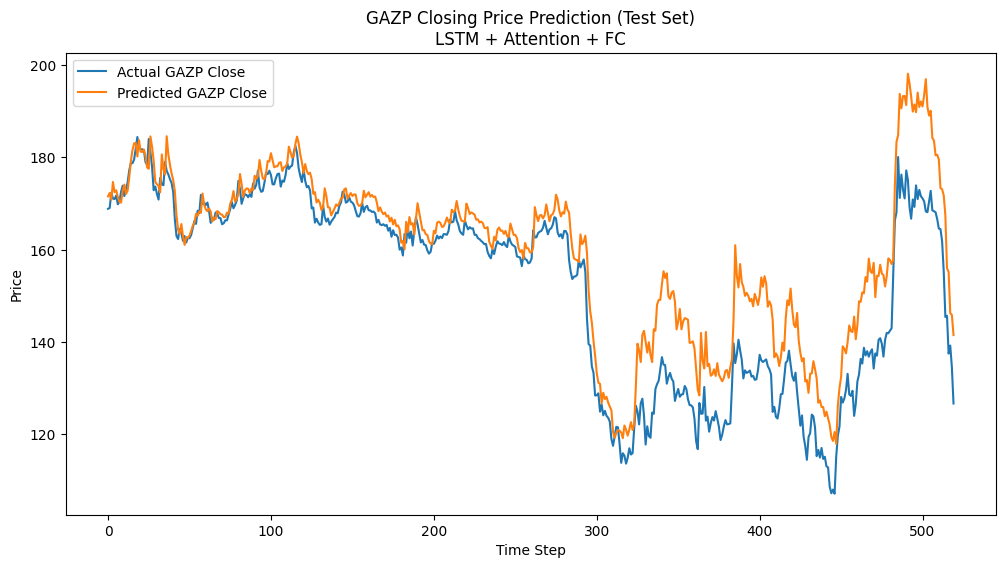

In [1]:
import os
import pickle
import requests
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import optuna

# ----------------------- Настройки и финансовые константы -----------------------
SEQ_LENGTH = 20          # Окно для временного ряда
TRAIN_TEST_RATIO = 0.8   # Доля данных для обучения
RSI_PERIOD = 14          # Период для расчёта RSI
SMA_WINDOW = 14          # Окно для скользящей средней
SEED = 42
TICKER = "GAZP"          # Меняем тикер здесь

torch.manual_seed(SEED)
np.random.seed(SEED)

# ----------------------- 1. Загрузка данных с MOEX -----------------------
def fetch_moex_eod_data(security, engine, market, board, start_date, end_date):
    base_url = f"https://iss.moex.com/iss/history/engines/{engine}/markets/{market}/boards/{board}/securities/{security}.json"
    all_data = []
    columns = None
    offset = 0
    limit = 100
    while True:
        params = {"from": start_date, "till": end_date, "start": offset}
        response = requests.get(base_url, params=params)
        if response.status_code != 200:
            print(f"Ошибка: HTTP {response.status_code}")
            break
        data = response.json()
        try:
            if columns is None:
                columns = data["history"]["columns"]
            page_data = data["history"]["data"]
            if not page_data:
                break
            all_data.extend(page_data)
            if len(page_data) < limit:
                break
            offset += limit
        except KeyError:
            print("Ошибка формата данных.")
            break
    if all_data and columns:
        return pd.DataFrame(all_data, columns=columns)
    else:
        return None

# ----------------------- 2. Технические индикаторы и финансовые преобразования -----------------------
def compute_rsi(series: pd.Series, period: int = RSI_PERIOD) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()
    rs = avg_gain / (avg_loss + 1e-10)
    return 100 - (100 / (1 + rs))

def compute_sma(series: pd.Series, window: int = SMA_WINDOW) -> pd.Series:
    return series.rolling(window=window).mean()

def compute_log_returns(series: pd.Series, window: int = 1) -> pd.Series:
    """Логарифмическая доходность для стабилизации ряда."""
    return np.log(series).diff(window)

def compute_volatility(series: pd.Series, window: int = SMA_WINDOW) -> pd.Series:
    """Волатильность как стандартное отклонение лог-доходностей."""
    returns = compute_log_returns(series)
    return returns.rolling(window=window).std()

def compute_macd(series: pd.Series, fast_period=12, slow_period=26, signal_period=9):
    """MACD: разница между быстрым и медленным EMA, сигнальная линия и гистограмма."""
    ema_fast = series.ewm(span=fast_period, adjust=False).mean()
    ema_slow = series.ewm(span=slow_period, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal_period, adjust=False).mean()
    macd_hist = macd_line - signal_line
    return macd_line, signal_line, macd_hist

def compute_bollinger_bands(series: pd.Series, window=20, num_std=2):
    """Bollinger Bands: верхняя, нижняя границы и SMA."""
    sma = series.rolling(window=window).mean()
    std = series.rolling(window=window).std()
    upper_band = sma + (std * num_std)
    lower_band = sma - (std * num_std)
    return upper_band, lower_band, sma

def compute_atr(df: pd.DataFrame, ticker: str, window: int = 14) -> pd.Series:
    """ATR: средний истинный диапазон для оценки волатильности."""
    high_col = f"HIGH_{ticker}"
    low_col = f"LOW_{ticker}"
    close_col = f"CLOSE_{ticker}"
    high_low = df[high_col] - df[low_col]
    high_prev_close = np.abs(df[high_col] - df[close_col].shift(1))
    low_prev_close = np.abs(df[low_col] - df[close_col].shift(1))
    true_range = pd.concat([high_low, high_prev_close, low_prev_close], axis=1).max(axis=1)
    atr = true_range.rolling(window=window).mean()
    return atr

# ----------------------- 3. Загрузка и кэширование данных -----------------------
def load_raw_data(ticker=TICKER, cache_file="raw_moex_data.pkl"):
    if os.path.exists(cache_file):
        with open(cache_file, "rb") as f:
            merged_df = pickle.load(f)
        print("Данные загружены из кэша.")
        return merged_df

    start_date = "2010-01-01"
    end_date = datetime.today().strftime("%Y-%m-%d")
    
    print(f"Загружаем данные {ticker} с MOEX...")
    ticker_df = fetch_moex_eod_data(ticker, "stock", "shares", "TQBR", start_date, end_date)
    print("Загружаем IMOEX...")
    imoex_df = fetch_moex_eod_data("IMOEX", "stock", "index", "SNDX", start_date, end_date)
    print("Загружаем USD/RUB...")
    usd_df = fetch_moex_eod_data("USD000UTSTOM", "currency", "selt", "CETS", start_date, end_date)
    
    if ticker_df is None or imoex_df is None or usd_df is None:
        raise ValueError("Ошибка при загрузке датасетов.")
    
    for df in [ticker_df, imoex_df, usd_df]:
        df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"])
        df.sort_values("TRADEDATE", inplace=True)
        df.reset_index(drop=True, inplace=True)
    
    # Переименовываем столбцы для выбранного тикера
    ticker_df.rename(columns={
        "CLOSE": f"CLOSE_{ticker}",
        "OPEN": f"OPEN_{ticker}",
        "HIGH": f"HIGH_{ticker}",
        "LOW": f"LOW_{ticker}",
        "VOLUME": f"VOL_{ticker}"
    }, inplace=True)
    imoex_df.rename(columns={"CLOSE": "CLOSE_IMOEX"}, inplace=True)
    usd_df.rename(columns={"CLOSE": "CLOSE_USD"}, inplace=True)
    
    ticker_df = ticker_df[["TRADEDATE", f"OPEN_{ticker}", f"HIGH_{ticker}", f"LOW_{ticker}", f"CLOSE_{ticker}", f"VOL_{ticker}"]]
    imoex_df = imoex_df[["TRADEDATE", "CLOSE_IMOEX"]]
    usd_df = usd_df[["TRADEDATE", "CLOSE_USD"]]
    
    merged_df = ticker_df.merge(imoex_df, on="TRADEDATE", how="outer") \
                         .merge(usd_df, on="TRADEDATE", how="outer")
    merged_df.sort_values("TRADEDATE", inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    merged_df.dropna(subset=[f"CLOSE_{ticker}", "CLOSE_IMOEX", "CLOSE_USD"], inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    
    with open(cache_file, "wb") as f:
        pickle.dump(merged_df, f)
    print("Данные сохранены в кэш.")
    return merged_df

# ----------------------- 4. Подготовка данных для модели -----------------------
def create_sequences(X, y, seq_length=SEQ_LENGTH):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

def prepare_data(raw_df: pd.DataFrame, ticker=TICKER):
    df = raw_df.copy()
    
    # Исходные финансовые признаки для выбранного тикера
    close_col = f"CLOSE_{ticker}"
    df['LOG_RETURNS'] = compute_log_returns(df[close_col])
    df['RSI'] = compute_rsi(df[close_col])
    df['SMA'] = compute_sma(df[close_col])
    df['VOLATILITY'] = compute_volatility(df[close_col])
    
    # Преобразование SMA в доходность (индикатор тренда)
    df['SMA_RETURNS'] = compute_log_returns(df['SMA'])
    
    # Дополнительные индикаторы:
    macd_line, macd_signal, macd_hist = compute_macd(df[close_col])
    df['MACD_LINE'] = macd_line
    df['MACD_SIGNAL'] = macd_signal
    df['MACD_HIST'] = macd_hist

    bb_upper, bb_lower, bb_middle = compute_bollinger_bands(df[close_col])
    df['BB_UPPER'] = bb_upper
    df['BB_LOWER'] = bb_lower
    df['BB_MIDDLE'] = bb_middle

    df['ATR'] = compute_atr(df, ticker=ticker, window=SMA_WINDOW)
    
    # Удаляем строки с NAN после вычислений
    df = df.dropna().reset_index(drop=True)
    
    # Разбиение на обучающую и тестовую выборки (с сохранением временного порядка)
    split_idx = int(len(df) * TRAIN_TEST_RATIO)
    train_df = df.iloc[:split_idx].copy()
    test_df  = df.iloc[split_idx:].copy()
    
    # Выбор признаков.
    features = [
        f"OPEN_{ticker}", f"HIGH_{ticker}", f"LOW_{ticker}", f"CLOSE_{ticker}", f"VOL_{ticker}",
        "CLOSE_IMOEX", "CLOSE_USD",
        "RSI", "SMA_RETURNS", "VOLATILITY", "LOG_RETURNS",
        "MACD_LINE", "MACD_SIGNAL", "MACD_HIST",
        "BB_UPPER", "BB_LOWER", "BB_MIDDLE",
        "ATR"
    ]
    target = f"CLOSE_{ticker}"  # прогнозируем цену закрытия выбранного тикера
    
    X_train = train_df[features].values.astype(float)
    X_test  = test_df[features].values.astype(float)
    y_train = train_df[[target]].values.astype(float)
    y_test  = test_df[[target]].values.astype(float)
    
    scaler_X = RobustScaler()
    scaler_y = RobustScaler()
    scaler_X.fit(X_train)
    scaler_y.fit(y_train)
    
    X_train_scaled = scaler_X.transform(X_train)
    X_test_scaled  = scaler_X.transform(X_test)
    y_train_scaled = scaler_y.transform(y_train)
    y_test_scaled  = scaler_y.transform(y_test)
    
    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled)
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled)
    
    train_dataset = TensorDataset(torch.tensor(X_train_seq, dtype=torch.float32),
                                  torch.tensor(y_train_seq, dtype=torch.float32))
    test_dataset = TensorDataset(torch.tensor(X_test_seq, dtype=torch.float32),
                                 torch.tensor(y_test_seq, dtype=torch.float32))
    
    # Для наивного прогноза определяем индекс цены закрытия в features
    close_idx = features.index(f"CLOSE_{ticker}")
    
    return train_dataset, test_dataset, scaler_X, scaler_y, close_idx, len(features)

# ----------------------- 5. Определение модели (LSTM + Attention) -----------------------
class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim, timesteps):
        super(AttentionLayer, self).__init__()
        self.hidden_dim = hidden_dim
        self.timesteps = timesteps
        self.W = nn.Parameter(torch.Tensor(hidden_dim, 1))
        self.b = nn.Parameter(torch.zeros(timesteps, 1))
        self.reset_parameters()
    
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.W)
    
    def forward(self, x):
        # x: (batch, timesteps, hidden_dim)
        e = torch.matmul(x, self.W) + self.b  # (batch, timesteps, 1)
        e = e.squeeze(-1)  # (batch, timesteps)
        alpha = torch.softmax(e, dim=1)  # (batch, timesteps)
        alpha = alpha.unsqueeze(-1)  # (batch, timesteps, 1)
        context = torch.sum(x * alpha, dim=1)
        return context

class PricePredictionModel(nn.Module):
    def __init__(self, seq_length, num_features, output_dim, lstm_units, fc_units, dropout_rate):
        super(PricePredictionModel, self).__init__()
        self.lstm = nn.LSTM(input_size=num_features, hidden_size=lstm_units, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.attention = AttentionLayer(hidden_dim=lstm_units, timesteps=seq_length)
        self.fc1 = nn.Linear(lstm_units, fc_units)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(fc_units, output_dim)
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        x = self.dropout(lstm_out)
        attn_out = self.attention(x)
        x = self.fc1(attn_out)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# ----------------------- 6. Обучение модели -----------------------
def train_model(trial=None, ticker=TICKER, n_epochs=40, patience=10):
    # Загрузка и подготовка данных
    raw_df = load_raw_data(ticker=ticker)
    train_dataset, test_dataset, scaler_X, scaler_y, close_idx, num_features = prepare_data(raw_df, ticker=ticker)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Если trial передан, оптимизируем гиперпараметры, иначе используем дефолтные
    if trial:
        lstm_units = trial.suggest_int("lstm_units", 50, 300)
        fc_units = trial.suggest_int("fc_units", 50, 300)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    else:
        lstm_units = 196
        fc_units = 151
        dropout_rate = 0.1335
        lr = 0.002688
        weight_decay = 4.77e-05

    model = PricePredictionModel(seq_length=SEQ_LENGTH, num_features=num_features, output_dim=1,
                                 lstm_units=lstm_units, fc_units=fc_units, dropout_rate=dropout_rate)
    model.to(device)
    
    criterion = nn.HuberLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(n_epochs):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())
        avg_train_loss = np.mean(train_losses)
        
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_losses.append(loss.item())
        avg_val_loss = np.mean(val_losses)
        scheduler.step(avg_val_loss)
        
        # Выводим информацию об эпохе
        print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_state = model.state_dict()
            if trial:
                trial.report(best_val_loss, epoch)
                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
        if device.type == 'cuda':
            torch.cuda.empty_cache()
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return model, scaler_y, test_loader, best_val_loss

# ----------------------- 7. Оптимизация гиперпараметров с помощью Optuna -----------------------
def objective(trial):
    _, _, _, best_val_loss = train_model(trial=trial, n_epochs=40, patience=10)
    return best_val_loss

if __name__ == "__main__":
    # Оптимизация гиперпараметров с помощью Optuna
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=50)
    
    print("Best trial:")
    trial = study.best_trial
    for key, value in trial.params.items():
        print(f"  {key}: {value}")
    
    # Финальное обучение с оптимальными гиперпараметрами
    best_model, scaler_y, test_loader, _ = train_model(trial=None, ticker=TICKER, n_epochs=40, patience=10)
    
    # Оценка финальной модели
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    best_model.to(device)
    best_model.eval()
    preds_list = []
    actual_list = []
    criterion = nn.HuberLoss()
    test_losses = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = best_model(X_batch)
            loss = criterion(outputs, y_batch)
            test_losses.append(loss.item())
            preds_list.append(outputs.cpu().numpy())
            actual_list.append(y_batch.cpu().numpy())
    avg_test_loss = np.mean(test_losses)
    print("Final Test Loss (Huber):", avg_test_loss)
    
    preds = np.concatenate(preds_list, axis=0)
    actuals = np.concatenate(actual_list, axis=0)
    
    preds_inv = scaler_y.inverse_transform(preds)
    actuals_inv = scaler_y.inverse_transform(actuals)
    
    mse_orig = mean_squared_error(actuals_inv, preds_inv)
    rmse_orig = np.sqrt(mse_orig)
    mae_orig = mean_absolute_error(actuals_inv, preds_inv)
    mape_orig = np.mean(np.abs((actuals_inv - preds_inv) / actuals_inv)) * 100
    
    print(f"\nМетрики для {TICKER}:")
    print(f"MSE: {mse_orig:.3f}")
    print(f"RMSE: {rmse_orig:.3f}")
    print(f"MAE: {mae_orig:.3f}")
    print(f"MAPE: {mape_orig:.2f}%")
    
    # Визуализация результатов
    plt.figure(figsize=(12,6))
    plt.plot(actuals_inv.flatten(), label=f"Actual {TICKER} Close")
    plt.plot(preds_inv.flatten(), label=f"Predicted {TICKER} Close")
    plt.title(f"{TICKER} Closing Price Prediction (Test Set)\nLSTM + Attention + FC")
    plt.xlabel("Time Step")
    plt.ylabel("Price")
    plt.legend()
    plt.show()
